
# QoS–QoE Unsupervised Learning Analysis

This notebook performs a **complete pipeline** on the engineered QoS/QoE dataset.

Pipeline:

1. Load dataset
2. Explore dataset
3. Select QoS features
4. Data preprocessing
5. Feature scaling
6. PCA dimensionality reduction
7. KMeans clustering
8. DBSCAN clustering
9. QoE analysis using MOS
10. QoE anomaly detection

Dataset path used:

```python
df = pd.read_csv("../data/engineered_dataset.csv")
```


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN

print("Libraries loaded")


Libraries loaded


## Load Dataset

In [2]:

df = pd.read_csv("../data/engineered_dataset.csv")

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()


Dataset shape: (300, 34)

Columns:
['QoS_bandwidth', 'QoS_packet-loss', 'QoS_delay', 'QoS_jitter', 'V_id-video', 'V_norm-bitrate', 'V_complexity', 'V_complexity-class', 'QoA_resolution', 'QoA-bitrate', 'QoA-frame_rate', 'QoA_frame-drop', 'QoA_audio-rate', 'QoA_audio-drop', 'QoD-cpu_mhz-moy', 'QoD-cpu_mhz-avg', 'QoD_cpu-nbr', 'QoD-cpu_core-nbr', 'QoD_stepping', 'QoD-cpu_bigo-mips', 'QoD_screen-mhz', 'QoD-ram_clock-speed', 'QoD_ram-size', 'MOS', 'screen_width', 'screen_height', 'screen_pixels', 'screen_dim_w', 'screen_dim_h', 'screen_area', 'V_content_Movie', 'QoD_carte-class_Radeon HD 7610M', 'QoD_carte-class_VGA compatible controller', 'QoD-screen_blug-type_LVDS']


,QoS_bandwidth,QoS_packet-loss,QoS_delay,QoS_jitter,V_id-video,V_norm-bitrate,V_complexity,V_complexity-class,QoA_resolution,QoA-bitrate,...,screen_width,screen_height,screen_pixels,screen_dim_w,screen_dim_h,screen_area,V_content_Movie,QoD_carte-class_Radeon HD 7610M,QoD_carte-class_VGA compatible controller,QoD-screen_blug-type_LVDS
0,1024,0.0,0.360,0.043,3,6.422284,5.874106,0,144,79.0,...,1366,768,1049088,361,203,73283,True,True,False,True
1,1024,0.0,0.435,0.071,3,6.422284,5.874106,0,144,79.0,...,1920,1200,2304000,508,317,161036,True,False,False,False
2,1024,0.0,0.403,0.033,3,6.422284,5.874106,0,144,79.0,...,1366,768,1049088,361,203,73283,True,True,False,True
3,1024,0.0,0.499,0.018,3,6.422284,5.874106,0,144,79.0,...,1366,768,1049088,361,203,73283,True,True,False,True
4,1024,0.0,0.472,0.034,3,6.422284,5.874106,0,144,79.0,...,1366,768,1049088,361,203,73283,True,True,False,True


## Basic Dataset Statistics

In [3]:

df.describe()


,QoS_bandwidth,QoS_packet-loss,QoS_delay,QoS_jitter,V_id-video,V_norm-bitrate,V_complexity,V_complexity-class,QoA_resolution,QoA-bitrate,...,QoD_screen-mhz,QoD-ram_clock-speed,QoD_ram-size,MOS,screen_width,screen_height,screen_pixels,screen_dim_w,screen_dim_h,screen_area
count,300.000000,300.0,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,...,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02,300.000000,300.000000,300.000000
mean,2324.480000,0.0,0.399090,0.051663,1.920000,6.926410,5.672476,0.640000,369.360000,734.608833,...,105.916667,1249.590000,3328.000000,3.203333,1522.700000,914.640000,1.488738e+06,402.440000,241.530000,103946.060000
std,1031.047853,0.0,0.071311,0.016980,0.822103,1.614496,0.273716,0.934511,256.720695,736.684892,...,42.916790,429.870053,1332.437603,1.314438,373.514955,259.363494,7.377831e+05,99.104214,68.646317,51630.368656
min,1024.000000,0.0,0.264000,0.018000,1.000000,5.412067,5.333550,0.000000,144.000000,78.400000,...,58.800000,533.000000,1024.000000,1.000000,1024.000000,600.000000,6.144000e+05,270.000000,158.000000,42660.000000
25%,1536.000000,0.0,0.330000,0.039000,1.000000,5.412067,5.333550,0.000000,240.000000,227.650000,...,72.075000,1133.000000,3328.000000,2.000000,1280.500000,726.000000,9.404160e+05,338.250000,191.750000,65627.250000
50%,2048.000000,0.0,0.407000,0.049000,2.000000,6.422284,5.874106,0.000000,240.000000,573.300000,...,76.500000,1333.000000,4096.000000,3.000000,1366.000000,768.000000,1.049088e+06,361.000000,203.000000,73283.000000
75%,3072.000000,0.0,0.465000,0.062250,3.000000,9.197309,5.874106,2.000000,480.000000,895.350000,...,154.000000,1600.000000,4096.000000,4.000000,1920.000000,1200.000000,2.304000e+06,508.000000,317.000000,161036.000000
max,4608.000000,0.0,0.534000,0.124000,3.000000,9.197309,7.008442,2.000000,1080.000000,3711.800000,...,154.000000,1600.000000,4096.000000,5.000000,2006.000000,1200.000000,2.407200e+06,508.000000,317.000000,161036.000000



## Select QoS Features

These features represent **network quality** and will be used for clustering.


In [4]:

qos_features = [
    "QoS_bandwidth",
    "QoS_packet-loss",
    "QoS_delay",
    "QoS_jitter"
]

X = df[qos_features].copy()

print("QoS Features used for clustering:")
print(qos_features)

X.head()


QoS Features used for clustering:
['QoS_bandwidth', 'QoS_packet-loss', 'QoS_delay', 'QoS_jitter']


,QoS_bandwidth,QoS_packet-loss,QoS_delay,QoS_jitter
0,1024,0.0,0.360,0.043
1,1024,0.0,0.435,0.071
2,1024,0.0,0.403,0.033
3,1024,0.0,0.499,0.018
4,1024,0.0,0.472,0.034


## QoE Feature

In [5]:

mos = df["MOS"]

print("MOS statistics:")
print(mos.describe())


MOS statistics:
count    300.000000
mean       3.203333
std        1.314438
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: MOS, dtype: float64


## Missing Values

In [6]:

print("Missing values per column:")
print(X.isna().sum())

X = X.fillna(X.median())

print("\nAfter cleaning:")
print(X.isna().sum())


Missing values per column:
QoS_bandwidth      0
QoS_packet-loss    0
QoS_delay          0
QoS_jitter         0
dtype: int64

After cleaning:
QoS_bandwidth      0
QoS_packet-loss    0
QoS_delay          0
QoS_jitter         0
dtype: int64


## Feature Scaling

In [7]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed")


Feature scaling completed


## PCA Dimensionality Reduction

In [8]:

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.43914803 0.33397199]


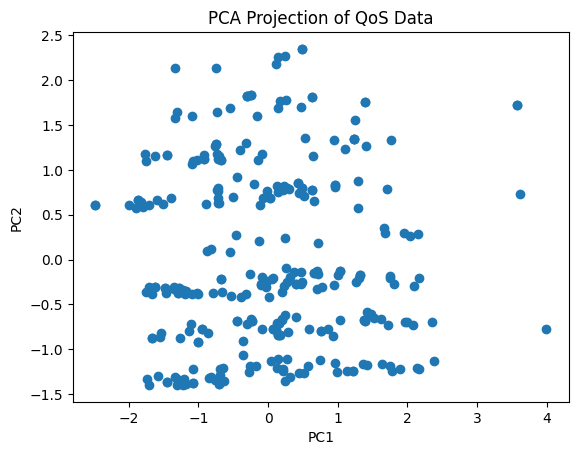

In [9]:

plt.figure()

plt.scatter(X_pca[:,0], X_pca[:,1])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of QoS Data")

plt.show()


## KMeans Clustering

In [10]:

kmeans = KMeans(n_clusters=4, random_state=42)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["kmeans_cluster"] = kmeans_labels

print("Cluster counts:")
print(pd.Series(kmeans_labels).value_counts())


Cluster counts:
1    91
3    83
2    73
0    53
Name: count, dtype: int64


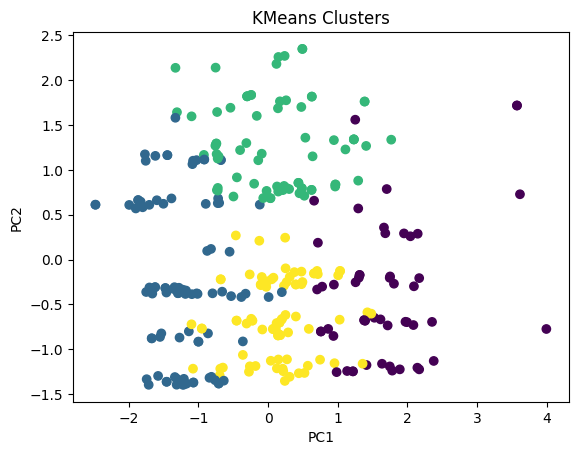

In [11]:

plt.figure()

plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters")

plt.show()


## DBSCAN Clustering

In [12]:

dbscan = DBSCAN(eps=0.5, min_samples=10)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["dbscan_cluster"] = dbscan_labels

print("Cluster counts including noise (-1):")
print(pd.Series(dbscan_labels).value_counts())


Cluster counts including noise (-1):
-1    205
 0     21
 2     18
 1     13
 3     13
 6     10
 5     10
 4     10
Name: count, dtype: int64


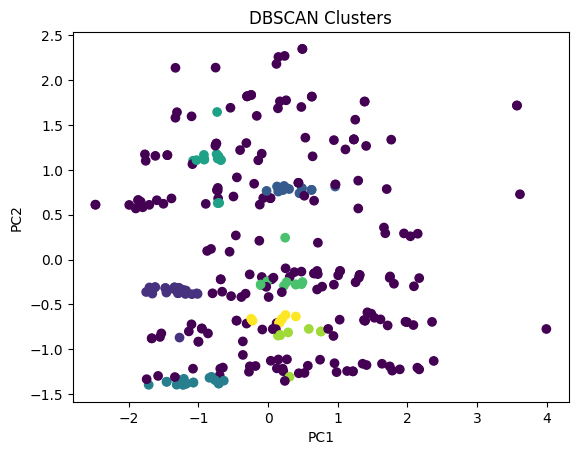

In [13]:

plt.figure()

plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters")

plt.show()


## QoE Analysis per Cluster

In [14]:

cluster_mos = df.groupby("kmeans_cluster")["MOS"].mean()

print("Average MOS per cluster:")
print(cluster_mos)


Average MOS per cluster:
kmeans_cluster
0    2.641509
1    3.296703
2    4.506849
3    2.313253
Name: MOS, dtype: float64



## QoE Anomaly Detection

Detect cases where:

QoS cluster looks normal but **MOS is significantly lower** than cluster average.


In [15]:

cluster_mean = df.groupby("kmeans_cluster")["MOS"].transform("mean")

df["qoe_anomaly"] = df["MOS"] < (0.5 * cluster_mean)

print("Number of QoE anomalies detected:")
print(df["qoe_anomaly"].sum())


Number of QoE anomalies detected:
38


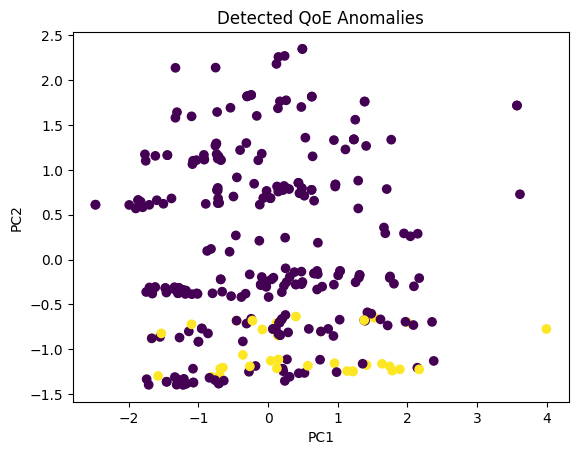

In [16]:

plt.figure()

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["qoe_anomaly"])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Detected QoE Anomalies")

plt.show()


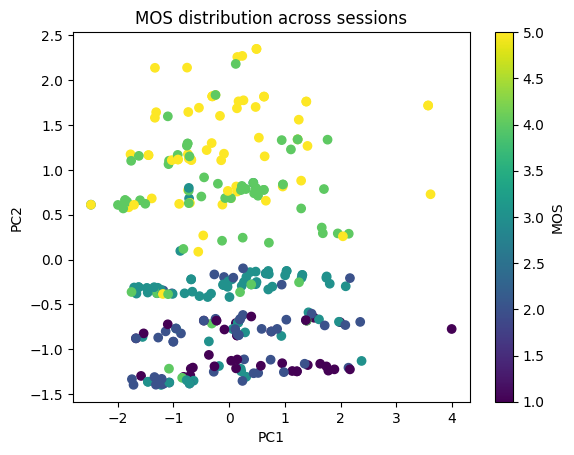

In [17]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["MOS"])

plt.title("MOS distribution across sessions")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="MOS")

plt.show()

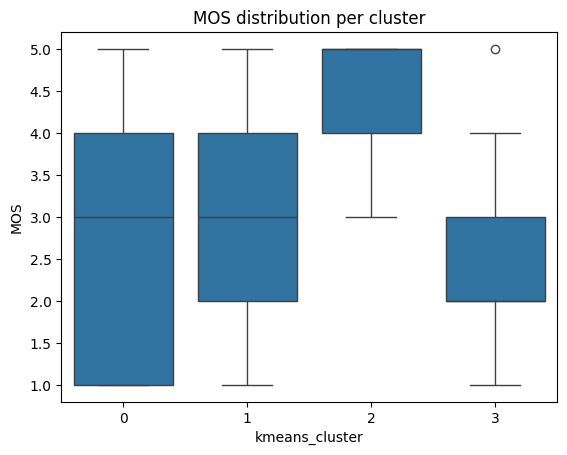

In [18]:
import seaborn as sns

sns.boxplot(x="kmeans_cluster", y="MOS", data=df)

plt.title("MOS distribution per cluster")

plt.show()